# 2km空间尺度下的只进只出区域匹配
通过ArcGIS将空间划分为2kmx2km的方形区域，然后统计得到只有出流和入流的区域,最后进行匹配

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
df2=pd.read_csv('北京边界数据.csv')   #北京边界
bj_x=df2["x"].tolist()
bj_y=df2["y"].tolist()

In [36]:
cy=39.91667   #北京市中心坐标
cx=116.41667

获得的只有入流和只有出流的区域的中心经纬度坐标，以及相互匹配的区域的经纬度坐标

In [3]:
#匹配区域的经纬度
pix=np.load('bj2kmpix.npy').tolist()
piy=np.load('bj2kmpiy.npy').tolist()
#只进/只出区域的经纬度坐标
xl=np.load('bj2kmx1.npy').tolist()
yl=np.load('bj2kmy1.npy').tolist()
xl1=np.load('bj2kmx11.npy').tolist()
yl1=np.load('bj2kmy11.npy').tolist()

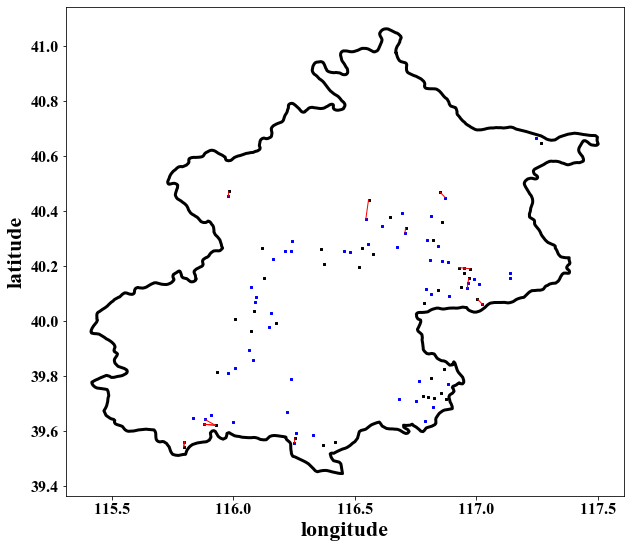

In [4]:
fig= plt.figure(figsize=(10,9))      #只有进流量的区域
ax = fig.add_subplot(1,1,1) 
 
fig.set_facecolor('white')
plt.plot(bj_x,bj_y,color="black",linewidth="3")

#plt.legend(loc="best")

ax.set_xlabel("longitude",fontdict={'size'   : 22,"family":"Times New Roman"})#经度
ax.set_ylabel("latitude",fontdict={ 'size'   : 22,"family":"Times New Roman"})#纬度
#ax.scatter(cen_x,cen_y,color="black",s=30)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman')
plt.tick_params(labelsize=16)
#ax.set_xlim(120.8,122.1)
#ax.set_ylim(30.6,31.6)
for i in range(0,len(pix)):
    x=pix[i]
    y=piy[i]  
    
    plt.plot(x,y,color="red",linewidth=1)
ax.scatter(xl,yl,alpha=1,color="black",marker="s",s=2,label="只进区域")
ax.scatter(xl1,yl1,alpha=1,color="blue",marker="s",s=2,label="只出区域")
